# Lab 6 Solution – Feedforward Neural Network on Insurance Premium Dataset

**Dataset:** [Insurance Premium (OpenML ID 43463)](https://www.openml.org/search?type=data&status=active&id=43463)

This notebook contains the complete solution with NumPy-based neural network implementation and comparison with sklearn's MLPRegressor.

In [ ]:
!pip install openml

## Q1. Load and Inspect Dataset

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

from sklearn.pipeline import Pipeline
import openml

# Load dataset
dataset = openml.datasets.get_dataset(43463)
# url = "https://www.openml.org/api/v1/json/data/43463"#https://www.openml.org/data/get_csv/20649148/insurance.csv"
df, _, _, _ = dataset.get_data(dataset_format="dataframe",)
# df = pd.read_csv(url)

# Show info
print(df.info())
print(df.head())


# Check for missing and duplicate values
print("Missing values per column:")
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   uint8  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   uint8  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), object(3), uint8(2)
memory usage: 55.0+ KB
None
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker  

## Q2. Train/Validation/Test Split

In [ ]:

# Separate features and target
X = df.drop(columns=['charges'])
y = df['charges'].values

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True,)*1

# Split into train, validation, test (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Train size:", X_train.shape, "Validation size:", X_val.shape, "Test size:", X_test.shape)


Train size: (936, 8) Validation size: (201, 8) Test size: (201, 8)


## Q3. Feature Preprocessing

In [ ]:
numeric_features = ["age", "bmi", "children"]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
      ],
    remainder="passthrough"
)

print(X_train.shape[1])
X_train = preprocessor.fit_transform(X_train)
print(X_train.shape[1])
X_val   = preprocessor.transform(X_val)
X_test  = preprocessor.transform(X_test)

# Reshape y for NN
y_train = y_train.reshape(-1, 1)
y_val   = y_val.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

print("Feature scaling done. Example scaled values:")
print(X_train[:5])

8
8
Feature scaling done. Example scaled values:
[[ 1.54446486  0.10318223 -0.91501097  0.          0.          1.
   0.          0.        ]
 [ 0.48187425 -0.4908445  -0.91501097  1.          0.          0.
   0.          1.        ]
 [ 1.04858924  0.2266597   1.56027883  0.          0.          0.
   1.          0.        ]
 [ 1.11942861  0.02392305 -0.91501097  1.          1.          0.
   0.          0.        ]
 [-1.00575261  2.50264978  0.73518223  1.          1.          0.
   1.          0.        ]]


## Q4. Custom Feedforward Neural Network (NumPy)

In [ ]:
class FeedforwardNN:
    def __init__(self, layers, lr=0.01, epochs=500, batch_size=32):
        self.layers = layers
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.params = {}

    def initialize_weights(self):
        np.random.seed(7)
        for i in range(1, len(self.layers)):
            self.params['W' + str(i)] = np.random.randn(self.layers[i-1], self.layers[i]) * 0.01
            self.params['b' + str(i)] = np.zeros((1, self.layers[i]))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, A):
        return np.where(A > 0, 1, 0)

    def forward(self, X):
        cache = {'A0': X}
        L = len(self.layers) - 1
        for i in range(1, L):
            Z = np.dot(cache['A'+str(i-1)], self.params['W'+str(i)]) + self.params['b'+str(i)]
            A = self.relu(Z)
            cache['Z'+str(i)] = Z
            cache['A'+str(i)] = A
        # Output layer (linear for regression)
        ZL = np.dot(cache['A'+str(L-1)], self.params['W'+str(L)]) + self.params['b'+str(L)]
        cache['Z'+str(L)] = ZL
        cache['A'+str(L)] = ZL
        return cache

    def compute_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred)**2)

    def backward(self, cache, y_true):
        grads = {}
        m = y_true.shape[0]
        L = len(self.layers) - 1

        dZ = 2*(cache['A'+str(L)] - y_true.reshape(-1,1)) / m
        grads['dW'+str(L)] = np.dot(cache['A'+str(L-1)].T, dZ)
        grads['db'+str(L)] = np.sum(dZ, axis=0, keepdims=True)

        for i in reversed(range(1, L)):
            dA = np.dot(dZ, self.params['W'+str(i+1)].T)
            dZ = dA * self.relu_derivative(cache['A'+str(i)])
            grads['dW'+str(i)] = np.dot(cache['A'+str(i-1)].T, dZ)
            grads['db'+str(i)] = np.sum(dZ, axis=0, keepdims=True)
        return grads

    def update_weights(self, grads):
        L = len(self.layers) - 1
        for i in range(1, L+1):
            self.params['W'+str(i)] -= self.lr * grads['dW'+str(i)]
            self.params['b'+str(i)] -= self.lr * grads['db'+str(i)]

    def fit(self, X, y, X_val=None, y_val=None):
        self.initialize_weights()
        history = {"train_loss": [], "val_loss": []}

        for epoch in range(self.epochs):
            for i in range(0, X.shape[0], self.batch_size):
                X_batch = X[i:i+self.batch_size]
                y_batch = y[i:i+self.batch_size]
                cache = self.forward(X_batch)
                grads = self.backward(cache, y_batch)
                self.update_weights(grads)

            # track losses
            train_pred = self.forward(X)['A'+str(len(self.layers)-1)]
            train_loss = self.compute_loss(y, train_pred)
            history["train_loss"].append(train_loss)

            if X_val is not None:
                val_pred = self.forward(X_val)['A'+str(len(self.layers)-1)]
                val_loss = self.compute_loss(y_val, val_pred)
                history["val_loss"].append(val_loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

        return history

    def predict(self, X):
        cache = self.forward(X)
        return cache['A'+str(len(self.layers)-1)].flatten()


## Q5. Hyperparameter Tuning (Example)

In [ ]:
# Define search space
hidden_layer_options = [2, 3]                 # number of hidden layers
neurons_options = [16, 32, 64]                   # neurons per layer

results = []

for num_layers in hidden_layer_options:
    for neurons in neurons_options:
        # Build architecture: input → hidden layers → output
        layer_sizes = [X_train.shape[1]] + [neurons]*num_layers + [1]

        nn = FeedforwardNN(layers=layer_sizes, lr=0.000001,epochs=1000, batch_size=8)
        nn.fit(X_train, y_train, X_val, y_val)

        # Evaluate on validation set
        y_val_pred = nn.predict(X_val)
        val_loss = np.mean((y_val - y_val_pred)**2)

        results.append((num_layers, neurons, val_loss))
        print(f"Layers={num_layers}, Neurons={neurons}, Val MSE={val_loss:.4f}")

# Pick best configuration
best_config = min(results, key=lambda x: x[2])
best_layers, best_neurons, best_val_loss = best_config
print(f"\nBest Config → Layers={best_layers}, Neurons={best_neurons}, Val Loss={best_val_loss:.4f}")

Epoch 0: Train Loss=325428294.0272, Val Loss=297378625.3291
Epoch 100: Train Loss=79491270.1270, Val Loss=71181761.8179
Epoch 200: Train Loss=58079734.2639, Val Loss=56107176.5476
Epoch 300: Train Loss=22514179.4112, Val Loss=27779110.5884
Epoch 400: Train Loss=20598605.4766, Val Loss=25248003.4558
Epoch 500: Train Loss=19284018.4025, Val Loss=24329926.0793
Epoch 600: Train Loss=20480978.8768, Val Loss=29669244.9215
Epoch 700: Train Loss=25851964.1820, Val Loss=44997870.4913
Epoch 800: Train Loss=18680464.2960, Val Loss=36948362.5909
Epoch 900: Train Loss=20313231.7069, Val Loss=30309480.9921
Layers=2, Neurons=16, Val MSE=286685785.7419
Epoch 0: Train Loss=325428145.9617, Val Loss=297378486.8010
Epoch 100: Train Loss=24135520.2458, Val Loss=28430159.9544
Epoch 200: Train Loss=24718751.6949, Val Loss=30694638.1824
Epoch 300: Train Loss=20955275.8642, Val Loss=27851520.1004
Epoch 400: Train Loss=18072988.0326, Val Loss=30937220.5753
Epoch 500: Train Loss=14539388.6579, Val Loss=28425627.

In [ ]:
# Experimented on values [16,32,64]
# layers [2,3]
# The best combination is shown below.
layers = [X_train.shape[1], 64, 128, 1]
nn = FeedforwardNN(layers=layers, lr=0.000001, epochs=2000, batch_size=8)
history = nn.fit(X_train, y_train, X_val, y_val)


Epoch 0: Train Loss=325427410.6335, Val Loss=297377799.5461
Epoch 100: Train Loss=23572379.5200, Val Loss=25829102.6367
Epoch 200: Train Loss=32867583.8544, Val Loss=47933330.5595
Epoch 300: Train Loss=19692162.1470, Val Loss=44603559.1463
Epoch 400: Train Loss=10853243.3456, Val Loss=40932778.8207
Epoch 500: Train Loss=15021028.7595, Val Loss=42875243.1436
Epoch 600: Train Loss=10945514.1411, Val Loss=39053762.7630
Epoch 700: Train Loss=6594585.0556, Val Loss=43292753.0857
Epoch 800: Train Loss=12047767.4242, Val Loss=46830851.4259
Epoch 900: Train Loss=8374231.8493, Val Loss=43970634.1707
Epoch 1000: Train Loss=4528735.9176, Val Loss=42614600.5951
Epoch 1100: Train Loss=6825820.2771, Val Loss=45257826.0647
Epoch 1200: Train Loss=5330168.4723, Val Loss=45065779.2112
Epoch 1300: Train Loss=3727069.2400, Val Loss=43452369.3199
Epoch 1400: Train Loss=4690978.0145, Val Loss=42873892.6361
Epoch 1500: Train Loss=2840496.6426, Val Loss=39956288.0006
Epoch 1600: Train Loss=2938547.6150, Val L

## Q6. Training & Validation Loss Curves

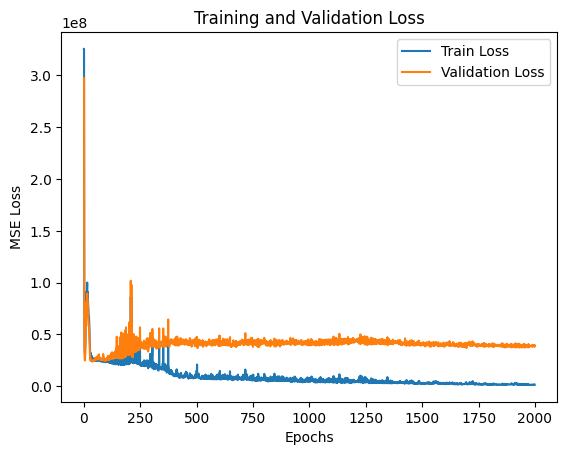

In [ ]:

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


## Q7. Evaluation on Test Set

Custom NN Test MSE: 42664599.620741926
Custom NN Test R2: 0.7186625047782653


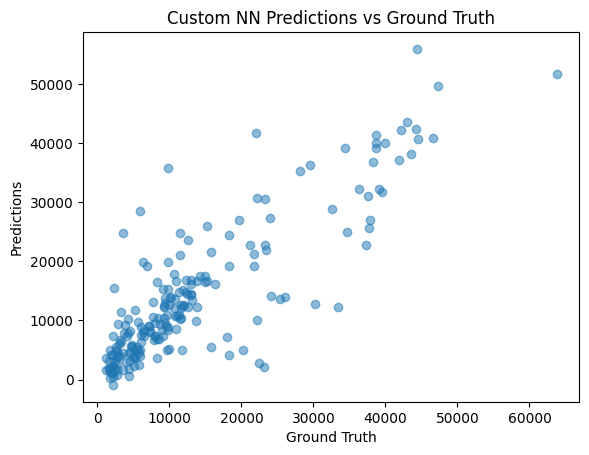

In [ ]:

y_pred_test = nn.predict(X_test)
y_pred_test_rounded = np.rint(y_pred_test)

mse_custom = mean_squared_error(y_test, y_pred_test_rounded)
r2_custom = r2_score(y_test, y_pred_test_rounded)

print("Custom NN Test MSE:", mse_custom)
print("Custom NN Test R2:", r2_custom)

plt.scatter(y_test, y_pred_test_rounded, alpha=0.5)
plt.xlabel("Ground Truth")
plt.ylabel("Predictions")
plt.title("Custom NN Predictions vs Ground Truth")
plt.show()


## Q8. Sklearn MLPRegressor

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Sklearn MLP Test MSE: 19356548.351734165
Sklearn MLP Test R2: 0.8723596874733642


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


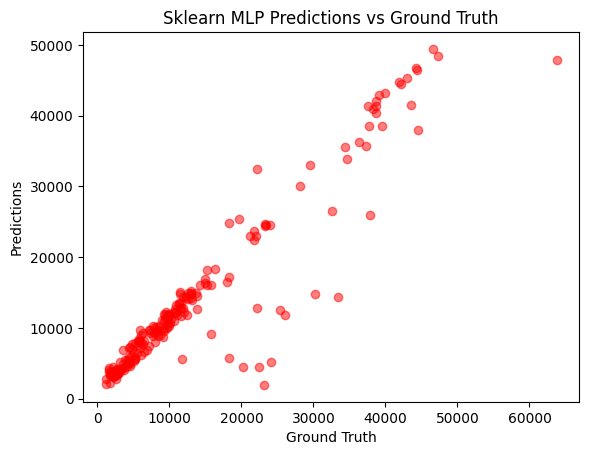

In [ ]:

mlp = MLPRegressor(hidden_layer_sizes=(64,128), max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
y_pred_mlp_rounded = np.rint(y_pred_mlp)

mse_mlp = mean_squared_error(y_test, y_pred_mlp_rounded)
r2_mlp = r2_score(y_test, y_pred_mlp_rounded)

print("Sklearn MLP Test MSE:", mse_mlp)
print("Sklearn MLP Test R2:", r2_mlp)

plt.scatter(y_test, y_pred_mlp_rounded, alpha=0.5, color='red')
plt.xlabel("Ground Truth")
plt.ylabel("Predictions")
plt.title("Sklearn MLP Predictions vs Ground Truth")
plt.show()
